# 7. Interpretación del modelo seleccionado

**Issue:** [#7 Interpretación del modelo seleccionado](https://github.com/velascocafe23/telco-churn-mlops/issues/7)

El modelo elegido es una regresión logística con umbral de decisión en 0.562, que obtuvo
F1 de 0.6205 y ROC-AUC de 0.8411 sobre el conjunto de prueba, sin superar al modelo base.

Este notebook responde tres preguntas: qué aprendió el modelo, qué errores comete, y a qué
se deben esos errores. La salida es un listado de experimentos para la siguiente
iteración, que es lo que el issue pide.

Que el modelo elegido sea lineal facilita la tarea: sus coeficientes son directamente
legibles y no hace falta recurrir a aproximaciones sobre una caja negra.

## 7.1 Configuración

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.metrics import brier_score_loss, confusion_matrix, f1_score
from sklearn.model_selection import learning_curve, train_test_split

INTERMEDIATE_FILE = Path("../../data/02_intermediate/telco_customer_churn.parquet")
MODELS_DIR = Path("../../models")
MODELO_FILE = MODELS_DIR / "modelo_churn.joblib"
METADATOS_FILE = MODELS_DIR / "modelo_churn_metadatos.json"

IDENTIFICADOR = "customerID"
OBJETIVO = "Churn"
CLASE_POSITIVA = "Yes"

PROPORCION_PRUEBA = 0.2
SEMILLA = 42
N_REPETICIONES = 10
N_ATRIBUTOS_MOSTRAR = 12
ZONA_INCERTIDUMBRE = 0.15

plt.rcParams["figure.dpi"] = 100

datos = pd.read_parquet(INTERMEDIATE_FILE)
modelo = joblib.load(MODELO_FILE)
metadatos = json.loads(METADATOS_FILE.read_text())

UMBRAL = metadatos["umbral_decision"]

atributos = datos.drop(columns=[IDENTIFICADOR, OBJETIVO])
objetivo = (datos[OBJETIVO] == CLASE_POSITIVA).astype(int)

atributos_ent, atributos_pru, objetivo_ent, objetivo_pru = train_test_split(
    atributos,
    objetivo,
    test_size=PROPORCION_PRUEBA,
    random_state=SEMILLA,
    stratify=objetivo,
)

probabilidades = modelo.predict_proba(atributos_pru)[:, 1]
prediccion = (probabilidades >= UMBRAL).astype(int)

print(f"Modelo:  {metadatos['familia']}")
print(f"Umbral:  {UMBRAL:.4f}")
print(f"F1:      {metadatos['metricas_prueba']['f1']}")

Modelo:  logistica
Umbral:  0.5619
F1:      0.6205


## 7.2 Coeficientes del modelo

En una regresión logística cada coeficiente indica cuánto cambia el logaritmo de las
probabilidades relativas ante un cambio unitario del atributo. Como el preprocesamiento
estandariza las numéricas y codifica las categóricas por indicadores, los coeficientes son
comparables entre sí en magnitud.

La exponencial del coeficiente es más fácil de comunicar: es el factor por el que se
multiplican las probabilidades relativas de cancelación.

In [2]:
nombres = modelo.named_steps["preprocesamiento"].get_feature_names_out()
coeficientes = modelo.named_steps["modelo"].coef_[0]

tabla_coeficientes = pd.DataFrame(
    {
        "atributo": [nombre.split("__", 1)[1] for nombre in nombres],
        "rama": [nombre.split("__")[0] for nombre in nombres],
        "coeficiente": coeficientes,
        "factor": np.exp(coeficientes),
    }
).sort_values("coeficiente", ascending=False)

print("Atributos que más aumentan la probabilidad de cancelación")
print(tabla_coeficientes.head(8).round(4).to_string(index=False))
print()
print("Atributos que más la reducen")
print(tabla_coeficientes.tail(8).round(4).to_string(index=False))

Atributos que más aumentan la probabilidad de cancelación
                      atributo        rama  coeficiente  factor
       Contract_Month-to-month categoricas       0.5000  1.6487
   InternetService_Fiber optic categoricas       0.3114  1.3653
                MonthlyCharges   numericas       0.2660  1.3047
PaymentMethod_Electronic check categoricas       0.2581  1.2945
                    tenure_0.0  antiguedad       0.2411  1.2726
             OnlineSecurity_No categoricas       0.2379  1.2686
                TechSupport_No categoricas       0.2149  1.2397
          PaperlessBilling_Yes categoricas       0.1565  1.1694

Atributos que más la reducen
           atributo        rama  coeficiente  factor
         tenure_1.0  antiguedad      -0.1304  0.8777
   MultipleLines_No categoricas      -0.1396  0.8697
    TechSupport_Yes categoricas      -0.1458  0.8643
PaperlessBilling_No categoricas      -0.1570  0.8547
 OnlineSecurity_Yes categoricas      -0.1689  0.8446
InternetService_DS

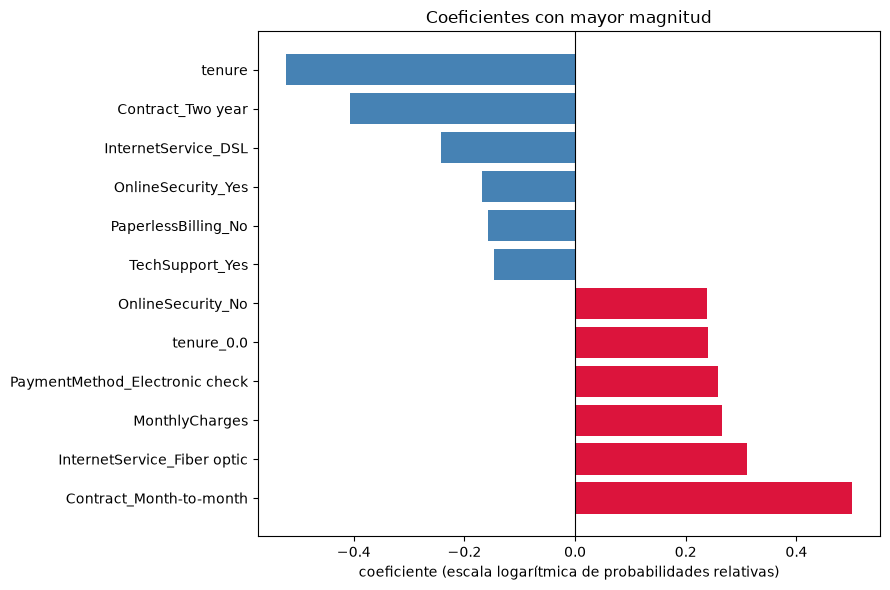

In [3]:
extremos = pd.concat(
    [
        tabla_coeficientes.head(N_ATRIBUTOS_MOSTRAR // 2),
        tabla_coeficientes.tail(N_ATRIBUTOS_MOSTRAR // 2),
    ]
)

figura, eje = plt.subplots(figsize=(9, 6))
colores = ["crimson" if valor > 0 else "steelblue" for valor in extremos["coeficiente"]]
eje.barh(extremos["atributo"], extremos["coeficiente"], color=colores)
eje.axvline(0, color="black", linewidth=0.8)
eje.set_title("Coeficientes con mayor magnitud")
eje.set_xlabel("coeficiente (escala logarítmica de probabilidades relativas)")
figura.tight_layout()
plt.show()

## 7.3 Importancia por permutación

Los coeficientes dicen cuánto pesa cada atributo dentro del modelo, pero no cuánto
depende el desempeño de él. Con atributos correlacionados, un coeficiente grande puede
estar compensando a otro sin que ninguno sea individualmente necesario.

La importancia por permutación mide lo segundo: cuánto se degrada el desempeño al
desordenar aleatoriamente los valores de un atributo. Se calcula sobre el conjunto de
prueba, con el ROC-AUC, para que la medida no dependa del umbral.

In [4]:
importancias = permutation_importance(
    modelo,
    atributos_pru,
    objetivo_pru,
    n_repeats=N_REPETICIONES,
    random_state=SEMILLA,
    scoring="roc_auc",
    n_jobs=-1,
)

tabla_importancias = pd.DataFrame(
    {
        "atributo": atributos_pru.columns,
        "caida_media": importancias.importances_mean,
        "desviacion": importancias.importances_std,
    }
).sort_values("caida_media", ascending=False)

tabla_importancias.head(N_ATRIBUTOS_MOSTRAR).round(5).reset_index(drop=True)

,atributo,caida_media,desviacion
0,tenure,0.07194,0.00357
1,Contract,0.02249,0.00306
2,InternetService,0.00607,0.00359
3,MonthlyCharges,0.00532,0.00293
4,OnlineSecurity,0.00368,0.00122
5,TechSupport,0.00337,0.00117
6,PaymentMethod,0.00336,0.00136
7,TotalCharges,0.00228,0.00070
8,PaperlessBilling,0.00223,0.00122
9,SeniorCitizen,0.00145,0.00048


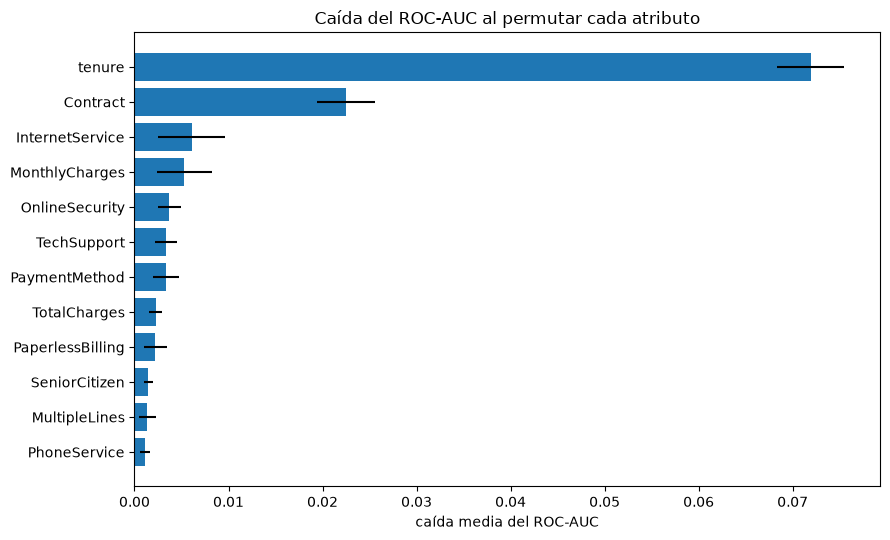

Atributos sin aporte medible: 1 de 19
['gender']


In [5]:
relevantes = tabla_importancias.head(N_ATRIBUTOS_MOSTRAR).iloc[::-1]

figura, eje = plt.subplots(figsize=(9, 5.5))
eje.barh(relevantes["atributo"], relevantes["caida_media"], xerr=relevantes["desviacion"])
eje.set_title("Caída del ROC-AUC al permutar cada atributo")
eje.set_xlabel("caída media del ROC-AUC")
figura.tight_layout()
plt.show()

sin_aporte = tabla_importancias[tabla_importancias["caida_media"] <= 0]
print(f"Atributos sin aporte medible: {len(sin_aporte)} de {len(tabla_importancias)}")
print(sin_aporte["atributo"].tolist())

## 7.4 Distribución de las probabilidades predichas

Antes de examinar los errores conviene ver cómo separa el modelo a las dos clases. El
grado de solapamiento entre ambas distribuciones determina el desempeño máximo alcanzable
con cualquier umbral.

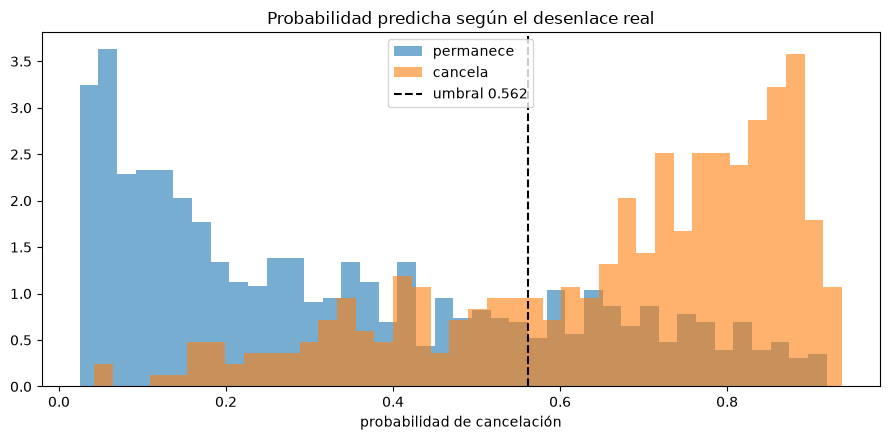

Probabilidad media, clientes que cancelaron:  0.6698
Probabilidad media, clientes que permanecen:  0.3316


In [6]:
figura, eje = plt.subplots(figsize=(9, 4.5))

eje.hist(
    probabilidades[objetivo_pru == 0],
    bins=40,
    alpha=0.6,
    label="permanece",
    density=True,
)
eje.hist(
    probabilidades[objetivo_pru == 1],
    bins=40,
    alpha=0.6,
    label="cancela",
    density=True,
)
eje.axvline(UMBRAL, color="black", linestyle="--", label=f"umbral {UMBRAL:.3f}")
eje.set_title("Probabilidad predicha según el desenlace real")
eje.set_xlabel("probabilidad de cancelación")
eje.legend()
figura.tight_layout()
plt.show()

print(
    f"Probabilidad media, clientes que cancelaron:  {probabilidades[objetivo_pru == 1].mean():.4f}"
)
print(
    f"Probabilidad media, clientes que permanecen:  {probabilidades[objetivo_pru == 0].mean():.4f}"
)

## 7.5 Calibración

Un modelo está bien calibrado si, entre los clientes a los que asigna una probabilidad de
0.3, aproximadamente el 30% cancela efectivamente. Importa para este proyecto: el equipo
de retención va a priorizar por probabilidad, y si esas probabilidades no son fiables, la
priorización tampoco lo es.

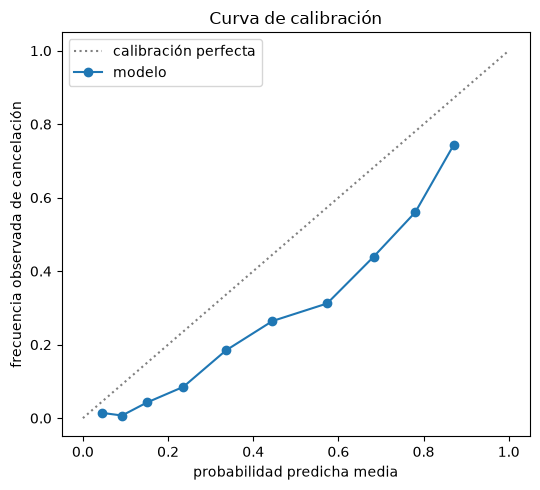

Puntaje de Brier: 0.1671
(menor es mejor; 0 sería predicción perfecta)


In [7]:
frecuencia_real, probabilidad_media = calibration_curve(
    objetivo_pru, probabilidades, n_bins=10, strategy="quantile"
)

figura, eje = plt.subplots(figsize=(5.5, 5))
eje.plot([0, 1], [0, 1], linestyle=":", color="gray", label="calibración perfecta")
eje.plot(probabilidad_media, frecuencia_real, marker="o", label="modelo")
eje.set_title("Curva de calibración")
eje.set_xlabel("probabilidad predicha media")
eje.set_ylabel("frecuencia observada de cancelación")
eje.legend()
figura.tight_layout()
plt.show()

print(f"Puntaje de Brier: {brier_score_loss(objetivo_pru, probabilidades):.4f}")
print("(menor es mejor; 0 sería predicción perfecta)")

## 7.6 Análisis de los errores

El modelo comete dos tipos de error con consecuencias muy distintas. Se caracterizan por
separado.

In [8]:
analisis = atributos_pru.copy()
analisis["real"] = objetivo_pru.to_numpy()
analisis["probabilidad"] = probabilidades
analisis["prediccion"] = prediccion

condiciones = [
    (analisis["real"] == 1) & (analisis["prediccion"] == 1),
    (analisis["real"] == 1) & (analisis["prediccion"] == 0),
    (analisis["real"] == 0) & (analisis["prediccion"] == 1),
    (analisis["real"] == 0) & (analisis["prediccion"] == 0),
]
etiquetas = ["acierto positivo", "no detectada", "contacto innecesario", "acierto negativo"]
analisis["resultado"] = np.select(condiciones, etiquetas, default="sin clasificar")

matriz = confusion_matrix(objetivo_pru, prediccion)
print(analisis["resultado"].value_counts().to_string())
print()
print(f"Cancelaciones no detectadas: {matriz[1, 0]} de {matriz[1].sum()}")
print(f"Contactos innecesarios:      {matriz[0, 1]} de {matriz[0].sum()}")

resultado
acierto negativo        802
acierto positivo        273
contacto innecesario    233
no detectada            101

Cancelaciones no detectadas: 101 de 374
Contactos innecesarios:      233 de 1035


In [9]:
perfil_errores = analisis.groupby("resultado", observed=True).agg(
    n=("tenure", "size"),
    antiguedad_mediana=("tenure", "median"),
    cargo_mensual_mediano=("MonthlyCharges", "median"),
    probabilidad_media=("probabilidad", "mean"),
)

perfil_errores.round(3)

,n,antiguedad_mediana,cargo_mensual_mediano,probabilidad_media
resultado,,,,
acierto negativo,802,48.0,55.175,0.220
acierto positivo,273,5.0,79.000,0.778
contacto innecesario,233,13.0,79.550,0.715
no detectada,101,28.0,59.900,0.378


In [10]:
for columna in ["Contract", "InternetService", "PaymentMethod"]:
    reparto = pd.crosstab(analisis[columna], analisis["resultado"], normalize="columns")
    print(f"\nDistribución de {columna} por tipo de resultado (%)")
    print((reparto * 100).round(1).to_string())


Distribución de Contract por tipo de resultado (%)
resultado       acierto negativo  acierto positivo  contacto innecesario  no detectada
Contract                                                                              
Month-to-month              27.2              98.5                  97.0          59.4
One year                    32.0               1.5                   3.0          31.7
Two year                    40.8               0.0                   0.0           8.9



Distribución de InternetService por tipo de resultado (%)
resultado        acierto negativo  acierto positivo  contacto innecesario  no detectada
InternetService                                                                        
DSL                          40.3              20.9                  27.5          39.6
Fiber optic                  23.9              79.1                  72.5          35.6
No                           35.8               0.0                   0.0          24.8

Distribución de PaymentMethod por tipo de resultado (%)
resultado                  acierto negativo  acierto positivo  contacto innecesario  no detectada
PaymentMethod                                                                                    
Bank transfer (automatic)              27.6              12.1                   9.4          23.8
Credit card (automatic)                28.1              11.0                  14.2          20.8
Electronic check                       16.7         

## 7.7 ¿Dónde se concentran los errores?

Si los errores se concentraran en probabilidades extremas, el modelo estaría equivocándose
con seguridad, que es el peor caso. Si se concentran alrededor del umbral, el modelo está
reconociendo su propia incertidumbre y el problema es la ambigüedad de los datos, no una
falla del modelo.

In [11]:
errores = analisis[analisis["resultado"].isin(["no detectada", "contacto innecesario"])]
aciertos = analisis[~analisis.index.isin(errores.index)]

distancia_errores = (errores["probabilidad"] - UMBRAL).abs()
distancia_aciertos = (aciertos["probabilidad"] - UMBRAL).abs()

en_zona_gris = (distancia_errores <= ZONA_INCERTIDUMBRE).mean()
aciertos_en_zona = (distancia_aciertos <= ZONA_INCERTIDUMBRE).mean()

print(f"Distancia mediana al umbral, errores:   {distancia_errores.median():.4f}")
print(f"Distancia mediana al umbral, aciertos:  {distancia_aciertos.median():.4f}")
print()
print(f"Errores dentro de ±{ZONA_INCERTIDUMBRE} del umbral:  {en_zona_gris:.1%}")
print(f"Aciertos dentro de ±{ZONA_INCERTIDUMBRE} del umbral: {aciertos_en_zona:.1%}")

Distancia mediana al umbral, errores:   0.1468
Distancia mediana al umbral, aciertos:  0.3130

Errores dentro de ±0.15 del umbral:  50.9%
Aciertos dentro de ±0.15 del umbral: 18.0%


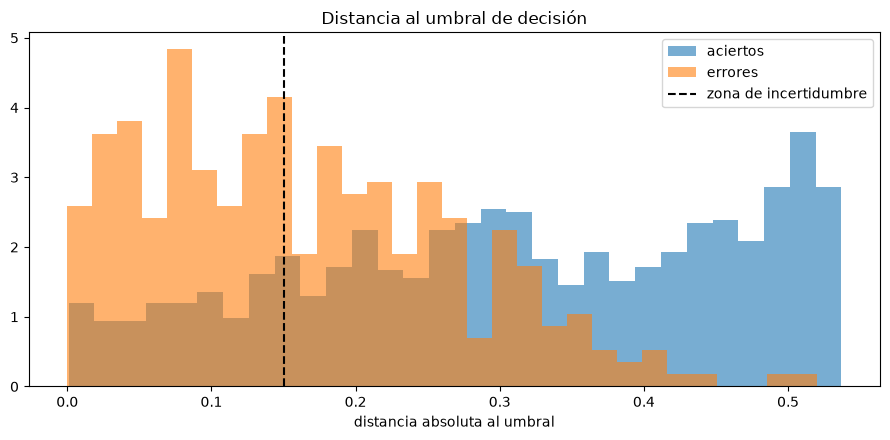

In [12]:
figura, eje = plt.subplots(figsize=(9, 4.5))
eje.hist(distancia_aciertos, bins=30, alpha=0.6, density=True, label="aciertos")
eje.hist(distancia_errores, bins=30, alpha=0.6, density=True, label="errores")
eje.axvline(ZONA_INCERTIDUMBRE, color="black", linestyle="--", label="zona de incertidumbre")
eje.set_title("Distancia al umbral de decisión")
eje.set_xlabel("distancia absoluta al umbral")
eje.legend()
figura.tight_layout()
plt.show()

## 7.8 Consecuencias de las malas predicciones

Las dos clases de error cuestan cosas distintas:

- **Cancelación no detectada**: se pierde el cliente y todo su valor futuro, sin que nadie
  haya intentado retenerlo. Es el error caro.
- **Contacto innecesario**: se entrega una oferta de retención a alguien que iba a
  quedarse. Cuesta el valor de la oferta y algo de desgaste comercial.

El umbral que maximiza el F1 trata ambos errores como equivalentes, lo cual no corresponde
a este problema. El cálculo siguiente muestra cuál sería el umbral óptimo según la
relación de costos, que es un dato del negocio y no del modelo.

In [13]:
razones_costo = [1, 2, 3, 5, 10, 20]
rejilla_umbrales = np.linspace(0.05, 0.95, 91)

resultados_costo = []
for razon in razones_costo:
    costos = []
    for umbral in rejilla_umbrales:
        marcado = (probabilidades >= umbral).astype(int)
        no_detectadas = int(((objetivo_pru == 1) & (marcado == 0)).sum())
        innecesarios = int(((objetivo_pru == 0) & (marcado == 1)).sum())
        costos.append(razon * no_detectadas + innecesarios)
    mejor = int(np.argmin(costos))
    marcado_optimo = (probabilidades >= rejilla_umbrales[mejor]).astype(int)
    resultados_costo.append(
        {
            "razon_costo": f"{razon} a 1",
            "umbral_optimo": round(float(rejilla_umbrales[mejor]), 3),
            "clientes_marcados": int(marcado_optimo.sum()),
            "cancelaciones_detectadas": int(((objetivo_pru == 1) & (marcado_optimo == 1)).sum()),
            "f1": round(f1_score(objetivo_pru, marcado_optimo), 4),
        }
    )

pd.DataFrame(resultados_costo)

,razon_costo,umbral_optimo,clientes_marcados,cancelaciones_detectadas,f1
0,1 a 1,0.71,316,205,0.5942
1,2 a 1,0.66,386,236,0.6211
2,3 a 1,0.41,682,323,0.6117
3,5 a 1,0.31,809,347,0.5866
4,10 a 1,0.28,853,354,0.5770
5,20 a 1,0.16,1035,369,0.5238


## 7.9 Causas de los errores

El issue plantea cuatro causas candidatas. Se revisa cada una con la evidencia disponible.

In [14]:
columnas_numericas = ["tenure", "MonthlyCharges", "TotalCharges"]

print("Valores atípicos entre los errores")
for columna in columnas_numericas:
    q1, q3 = atributos_pru[columna].quantile([0.25, 0.75])
    rango = q3 - q1
    limite_inferior, limite_superior = q1 - 1.5 * rango, q3 + 1.5 * rango
    atipicos_errores = (
        (errores[columna] < limite_inferior) | (errores[columna] > limite_superior)
    ).mean()
    print(f"  {columna:16s} {atipicos_errores:.2%} de los errores son atípicos")

print()
print("Reparto de los errores por clase real")
reparto_errores = errores["real"].value_counts(normalize=True)
print(f"  Clase minoritaria (cancela):  {reparto_errores.get(1, 0):.1%}")
print(f"  Clase mayoritaria (permanece): {reparto_errores.get(0, 0):.1%}")

Valores atípicos entre los errores
  tenure           0.00% de los errores son atípicos
  MonthlyCharges   0.00% de los errores son atípicos
  TotalCharges     0.00% de los errores son atípicos

Reparto de los errores por clase real
  Clase minoritaria (cancela):  30.2%
  Clase mayoritaria (permanece): 69.8%


In [15]:
categoricas = atributos_pru.select_dtypes(include="category").columns

categorias_no_vistas = {
    columna: sorted(
        set(atributos_pru[columna].dropna().unique())
        - set(atributos_ent[columna].dropna().unique())
    )
    for columna in categoricas
}

faltantes = {col: vals for col, vals in categorias_no_vistas.items() if vals}

print(f"Categorías presentes en prueba y ausentes en entrenamiento: {faltantes}")
print(f"Valores ausentes en el conjunto de prueba: {int(atributos_pru.isna().sum().sum())}")

Categorías presentes en prueba y ausentes en entrenamiento: {}
Valores ausentes en el conjunto de prueba: 3


## 7.10 Curva de aprendizaje y escalabilidad del modelo final

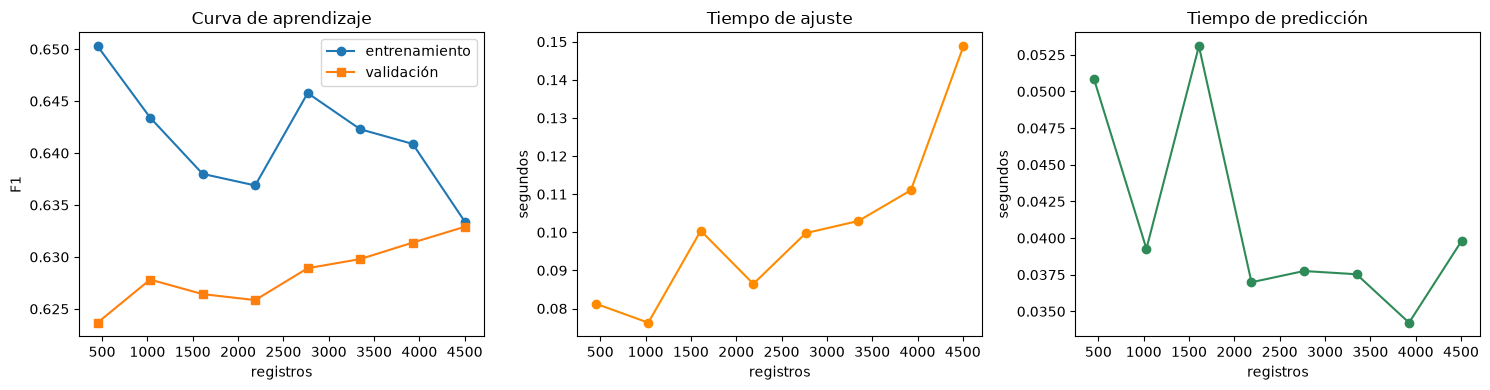

Ajuste con el conjunto completo:     0.1488 s
Predicción sobre el conjunto de validación: 0.0398 s


In [16]:
tamanos, puntaje_ent, puntaje_val, tiempos_ajuste, tiempos_prediccion = learning_curve(
    modelo,
    atributos_ent,
    objetivo_ent,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=5,
    scoring="f1",
    return_times=True,
    random_state=SEMILLA,
    n_jobs=-1,
)

figura, ejes = plt.subplots(1, 3, figsize=(15, 4))

ejes[0].plot(tamanos, puntaje_ent.mean(axis=1), marker="o", label="entrenamiento")
ejes[0].plot(tamanos, puntaje_val.mean(axis=1), marker="s", label="validación")
ejes[0].set_title("Curva de aprendizaje")
ejes[0].set_xlabel("registros")
ejes[0].set_ylabel("F1")
ejes[0].legend()

ejes[1].plot(tamanos, tiempos_ajuste.mean(axis=1), marker="o", color="darkorange")
ejes[1].set_title("Tiempo de ajuste")
ejes[1].set_xlabel("registros")
ejes[1].set_ylabel("segundos")

ejes[2].plot(tamanos, tiempos_prediccion.mean(axis=1), marker="o", color="seagreen")
ejes[2].set_title("Tiempo de predicción")
ejes[2].set_xlabel("registros")
ejes[2].set_ylabel("segundos")

figura.tight_layout()
plt.show()

print(f"Ajuste con el conjunto completo:     {tiempos_ajuste.mean(axis=1)[-1]:.4f} s")
print(f"Predicción sobre el conjunto de validación: {tiempos_prediccion.mean(axis=1)[-1]:.4f} s")

## 7.11 Conclusiones y experimentos para la siguiente iteracion

### Que aprendio el modelo

Los coeficientes reproducen fielmente lo que encontro el analisis exploratorio, lo que es
una senal de coherencia del proyecto. Aumentan la probabilidad de cancelacion: contrato
mes a mes (factor 1.65), internet por fibra optica (1.37), cargo mensual alto (1.30),
pago por cheque electronico (1.29) y el primer tramo de antiguedad (1.27). La reducen: la
antiguedad como magnitud continua (factor 0.59, el coeficiente de mayor magnitud del
modelo) y el contrato a dos anos (0.67).

### Coeficientes contra permutacion: dos preguntas distintas

Por permutacion, `tenure` domina con una caida de 0.072 del ROC-AUC, muy por encima de
`Contract` con 0.022. Esto parece contradecir el modelo base, donde `Contract` en
solitario alcanzaba el 91.6% del F1 del modelo completo.

No hay contradiccion: las dos medidas responden preguntas distintas. Un atributo evaluado
en solitario mide **cuanta informacion contiene**. La permutacion mide **cuanta
informacion aporta que no este ya en los demas atributos**. Como el pipeline incluye la
antiguedad discretizada en tramos, y esos tramos capturan buena parte de lo que distingue
a los contratos, al permutar `Contract` el modelo se apoya en ellos y apenas se degrada.
La antiguedad, en cambio, no tiene sustituto.

De los diecinueve atributos, **solo `gender` no tiene aporte medible**. El resto
contribuye, aunque sea marginalmente.

### Donde se equivoca el modelo

| Resultado | Casos | Antiguedad mediana | Cargo mensual mediano | Probabilidad media |
|---|---|---|---|---|
| Acierto negativo | 802 | 48 meses | 55.2 | 0.220 |
| Acierto positivo | 273 | 5 meses | 79.0 | 0.778 |
| Contacto innecesario | 233 | 13 meses | 79.6 | 0.715 |
| Cancelacion no detectada | 101 | 28 meses | 59.9 | 0.378 |

El perfil de los errores es revelador. Las **cancelaciones no detectadas tienen antiguedad
mediana de 28 meses**, frente a 5 meses de los aciertos positivos: son clientes
establecidos que se van sin presentar las senales habituales de riesgo. Los **contactos
innecesarios tienen cargos mensuales altos y antiguedad baja**, es decir, se parecen mucho
a quienes si cancelan.

### El hallazgo central: el modelo se equivoca donde no esta seguro

| Medida | Errores | Aciertos |
|---|---|---|
| Distancia mediana al umbral | 0.147 | 0.313 |
| Dentro de ±0.15 del umbral | 50.9% | 18.0% |

La mitad de los errores ocurre en la franja inmediata al umbral, donde el modelo esta
practicamente indeciso, mientras que solo el 18% de los aciertos cae en esa misma franja.

Esto cambia el diagnostico. **El modelo no se equivoca con seguridad**, que seria el caso
grave y sugeriria un problema de especificacion o de sesgo. Se equivoca donde reconoce su
propia incertidumbre, que es el comportamiento esperable ante datos ambiguos. Concuerda
directamente con el 6.1% de perfiles de servicio con desenlace mixto que hallo el analisis
exploratorio: en esa zona conviven clientes identicos con desenlaces opuestos, y ninguna
eleccion de modelo puede resolverlo.

### Calidad de las probabilidades

El puntaje de Brier es 0.1671 y la separacion entre clases es clara: probabilidad media de
0.670 entre quienes cancelaron contra 0.332 entre quienes permanecieron. Las
probabilidades son utilizables para priorizar, que es como el equipo de retencion va a
consumir el modelo.

### Descarte de causas de error

El issue plantea cuatro causas candidatas. La evidencia descarta tres:

| Causa | Evidencia | Veredicto |
|---|---|---|
| Valores atipicos | 0% de los errores son atipicos por rango intercuartilico | Descartada |
| Codificadores | Ninguna categoria de prueba ausente en entrenamiento | Descartada |
| Errores de captura | Solo 3 ausentes en prueba, estructurales por antiguedad cero | Descartada |
| Desbalance de clases | 69.8% de los errores son contactos innecesarios | **Contribuye** |

El desbalance sigue presente pese a la ponderacion: casi siete de cada diez errores son
falsos positivos. Es consecuencia directa de haber optimizado el umbral hacia la deteccion,
y es el intercambio que se acepto conscientemente.

La causa real no esta en esa lista: **es la ausencia de informacion discriminante** para
los clientes de la zona ambigua.

### Consecuencias de las malas predicciones

El umbral optimo depende de cuanto mas cueste perder un cliente que enviar una oferta
innecesaria:

| Relacion de costos | Umbral optimo | Clientes marcados | Cancelaciones detectadas |
|---|---|---|---|
| 1 a 1 | 0.71 | 316 | 205 de 374 |
| 2 a 1 | 0.66 | 386 | 236 de 374 |
| 3 a 1 | 0.41 | 682 | 323 de 374 |
| 5 a 1 | 0.31 | 809 | 347 de 374 |
| 10 a 1 | 0.28 | 853 | 354 de 374 |
| 20 a 1 | 0.16 | 1035 | 369 de 374 |

La tabla traduce una decision de negocio a una configuracion del sistema. Si perder un
cliente cuesta cinco veces mas que una oferta innecesaria, conviene marcar 809 clientes de
1409 y capturar 347 de las 374 cancelaciones. Si la relacion es 2 a 1, basta con marcar
386 y se capturan 236.

Notese que el umbral que maximiza el F1 (0.562) corresponde aproximadamente a una relacion
de costos entre 2 y 3 a 1. **Usar el F1 como criterio equivale a asumir esa relacion sin
declararla**, y es preferible hacerla explicita.

### Costo operativo

El modelo se ajusta en 0.15 segundos sobre el conjunto completo y predice en 0.04
segundos. El reentrenamiento mensual es practicamente gratuito, lo que respalda la
eleccion de la familia mas simple hecha en la etapa anterior.

### Experimentos para la siguiente iteracion

**Sobre los datos**

1. **Incorporar atributos de comportamiento**: reclamos, incidencias de servicio,
   interacciones con soporte. Es la unica via que puede reducir la zona ambigua donde se
   concentra la mitad de los errores.
2. **Investigar el segmento de cancelaciones no detectadas**: clientes con 28 meses de
   antiguedad mediana que se van sin senales previas. Entender por que se fueron es un
   problema de negocio antes que de modelado.
3. **Eliminar `gender`** del conjunto de atributos: no aporta y su uso en decisiones
   comerciales es cuestionable.
4. **Anadir el atributo de vinculacion** (numero de servicios contratados), pendiente
   desde la etapa de ingenieria de atributos.

**Sobre el modelo**

5. **Modelo especifico para el segmento de contrato mes a mes**, que concentra el riesgo.
6. **Exponer la probabilidad, no solo la clasificacion binaria**, dado que la separacion
   entre clases es utilizable para priorizar.

**Decisiones de negocio pendientes**

7. **Fijar la relacion de costos entre los dos tipos de error.** Es el dato que falta para
   elegir el umbral con fundamento, y no corresponde al equipo de datos definirlo.
8. **Definir la capacidad operativa del equipo de retencion**, que acota cuantos clientes
   tiene sentido marcar por ciclo.

**Siguiente paso:** demostracion local del modelo.